In [33]:
# Importación de librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [35]:
# Carga de datos
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [37]:
#Selección de columnas para el trabajo
df = df[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]]

# Convertir TotalCharges a numérico
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Eliminar nulos
df = df.dropna()

# Convertir Churn a numérico
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

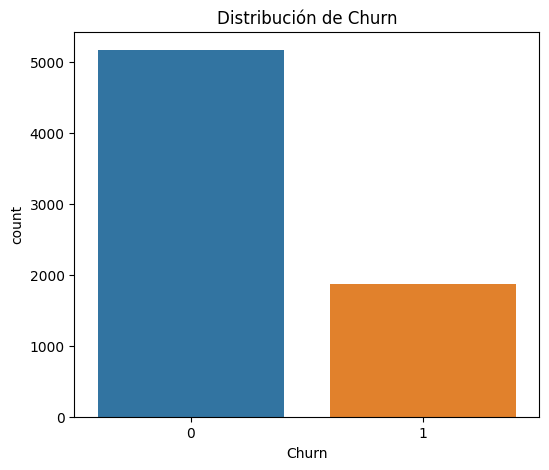

In [39]:
# Countplot de Churn
plt.figure(figsize=(6,5))

sns.countplot(x="Churn", data=df)

plt.title("Distribución de Churn")

plt.show()

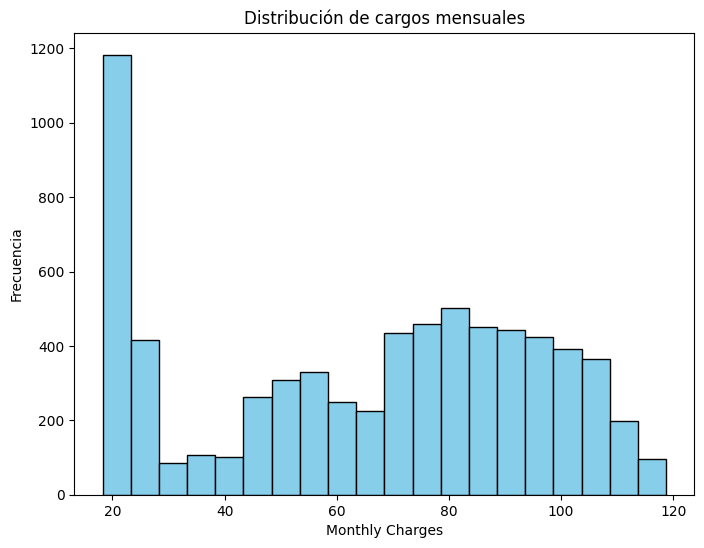

In [41]:
# Histograma
plt.figure(figsize=(8,6))

plt.hist(
    df["MonthlyCharges"],
    bins=20,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribución de cargos mensuales")
plt.xlabel("Monthly Charges")
plt.ylabel("Frecuencia")

plt.show()

In [45]:
# Variables predictoras y objetivo
X = df.drop("Churn", axis=1)

y = df["Churn"]

# División de datos

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
# Escalado
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

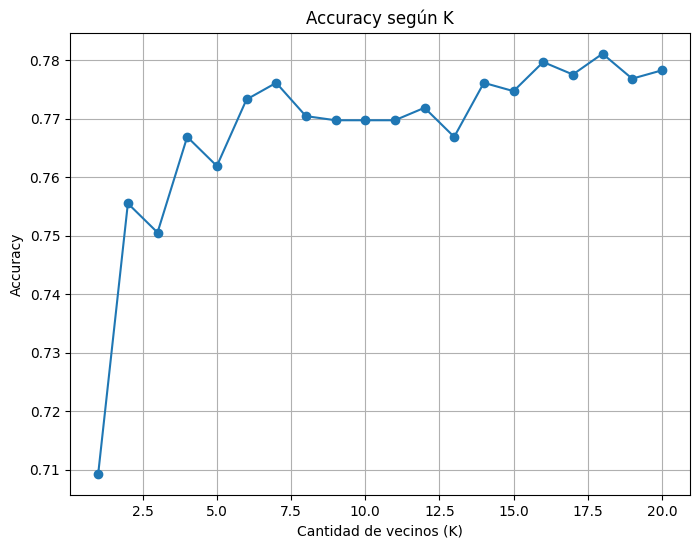

In [49]:
# Gráfico Accuracy según K
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 21)

accuracies = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)

# Gráfico

plt.figure(figsize=(8,6))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.title("Accuracy según K")
plt.xlabel("Cantidad de vecinos (K)")
plt.ylabel("Accuracy")

plt.grid()

plt.show()

In [51]:
# Modelo K-NN
knn = KNeighborsClassifier(n_neighbors=18)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

# Accuracy KNN
print("Accuracy KNN:",
      accuracy_score(y_test, knn_pred))

Accuracy KNN: 0.7810945273631841


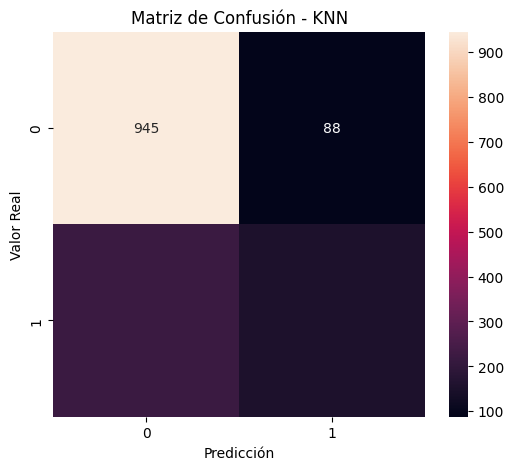

In [53]:
# Matriz de confusión K-NN
cm_knn = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusión - KNN")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [55]:
# Arbol de Desición
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

# Accuracy Árbol
print("Accuracy Árbol:",
      accuracy_score(y_test, tree_pred))

Accuracy Árbol: 0.7192608386638237


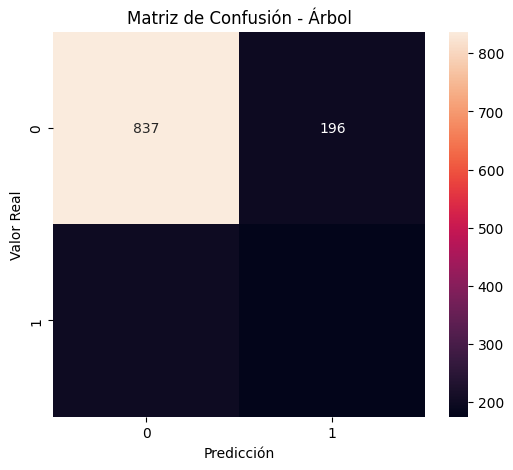

In [23]:
# Matriz de Confusión Arbol de Decisión
cm_tree = confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusión - Árbol")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()


In [25]:
# Reportes
print("\nReporte KNN")
print(classification_report(y_test, knn_pred))

print("\nReporte Árbol")
print(classification_report(y_test, tree_pred))


Reporte KNN
              precision    recall  f1-score   support

           0       0.81      0.88      0.84      1033
           1       0.57      0.45      0.50       374

    accuracy                           0.76      1407
   macro avg       0.69      0.66      0.67      1407
weighted avg       0.75      0.76      0.75      1407


Reporte Árbol
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.47      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407

